# Data Encoding Schemes and Feature Maps
This notebook present short description and syntax for various data encoding schemes, also known as feature maps.

If you are running this notebook in VS code, your environment must have the following libraries installed. If you are running this in google colab, you need to install the following libraries.

`qiskit, qiskit-aer, matplotlib, pylatexenc`

In [1]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pylatexenc
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 28.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=8ba3ddea8e26aa18af32884fcd461d453bd310999548d416f654f8c903bae4e9
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 7.5 MB/s eta 0:00:00


In [33]:
import qiskit
import qiskit_aer
import qiskit_ibm_runtime
import qiskit_machine_learning

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Qiskit IBM-runtime version:", qiskit_ibm_runtime.__version__)
print("Qiskit ML version:", qiskit_machine_learning.__version__)

Qiskit version: 2.5.0
Qiskit Aer version: 0.17.2
Qiskit IBM-runtime version: 0.48.0
Qiskit ML version: 0.9.0


References:
1. Data encoding: https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding

2. QML tutorial: https://qiskit-community.github.io/qiskit-machine-learning/index.html

### 1. Basis Encoding
Suppose all features are stored in four bits like

5 → binary 0101

7 → binary 0111

0 → binary 0000

These bit strings are assigned to three sets of four qubits, so the overall 12-qubit basis state is: ∣0101 0111 0000⟩. Here, the first four qubits represent the first feature, the next four qubits the second feature, and the last four qubits the third feature. The code below converts the data vector (5,7,0) to a quantum state, and is generalized to do so for other single-digit features.

Basis Encoding Circuit:


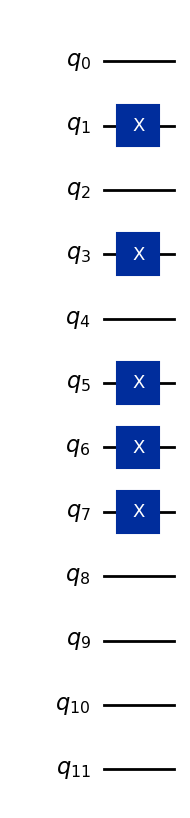

In [4]:
from qiskit import QuantumCircuit

# Data point to encode
x = 5  # binary: 0101
y = 7  # binary: 0111
z = 0  # binary: 0000

# u= -5
# u_bits = [int(b) for b in format(u & 0xf, '04b')]


# Convert each to 4-bit binary list
#format(x, "04b")-does the actual binary conversion.
x_bits = [int(b) for b in format(x, "04b")]  # [0,1,0,1]
y_bits = [int(b) for b in format(y, "04b")]  # [0,1,1,1]
z_bits = [int(b) for b in format(z, "04b")]  # [0,0,0,0]

"""
b: Specifies binary format (base 2). For example, 5 becomes '101'.
4: Specifies the minimum width of the output string.
0: Specifies zero-padding. If the binary string is shorter than 4 characters,
it pads it with leading zeros on the left.
"""

# Combine all bits
all_bits = x_bits + y_bits + z_bits  # [0,1,0,1,0,1,1,1,0,0,0,0]

num_qubits = len(all_bits)
# num_qubits = 4+4+4 =12
# Initialize a 12-qubit quantum circuit
qc = QuantumCircuit(num_qubits)

# Apply x-gates where the bit is 1
for idx, bit in enumerate(all_bits):
  if bit == 1:
    qc.x(idx)

"""
In Python, enumerate() is a built-in function used to loop through an iterable (like a list, tuple, or string)
while keeping track of both the index (the position) and the value of each item at the same time.
"""

print("Basis Encoding Circuit:")
qc.draw("mpl")

### 2. Amplitude Encoding
In amplitude encoding, each feature in a data vector is stored as an amplitude of a different quantum state. As an example, let's encode the first vector in our example dataset $\text{X}_\text{ex}$, $\vec{x}^{(1)} = (4,8,5)$ using amplitude encoding. Normalizing the resulting vector, we get:
$$
\sum_{i=1}^N \left|x^{(1)}_i\right|^2 = 4^2+8^2+5^2 = 105 = \left|\alpha\right|^2 \rightarrow \alpha = \sqrt{105}
$$
and the resulting 2-qubit quantum state would be:
$$
|\psi(\vec{x}^{(1)})\rangle = \frac{1}{\sqrt{105}}(4|00\rangle+8|01\rangle+5|10\rangle+0|11\rangle)
$$

In the example above, the number of features in the vector $N=3$, is not a power of 2. When $N$ is not a power of 2, we simply choose a value for the number of qubits $n$ such that $2^n\geq N$ and pad the amplitude vector with uninformative constants (here, a zero) so amplitude encoding of $N$ features requires $n \ge \mathrm{log}_2(N)$ qubits.

We can implement amplitude encoding easily in qiskit using initialize method as follows:

The initialize function is used to prepare a quantum circuit in a specific, predetermined quantum state. By default, qubits in a quantum circuit always start in the ground state $|0\rangle$. If we want our qubits to represent a specific vector of classical data (such as a normalized array of numbers for Machine Learning), `initialize` automatically generates the necessary quantum gates to transition the qubits into that exact state.

`initialize()` is a high-level state-preparation routine. Here, Qiskit internally:

1. Computes a state-preparation algorithm.
2. Decomposes it into:
$R_y$, $R_z$, CNOTs.
3. Generates a circuit that produces the desired amplitudes.

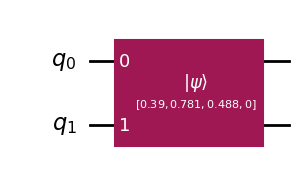

In [5]:
import math

desired_state = [
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]

qc = QuantumCircuit(2)
qc.initialize(desired_state, [0, 1])
"""[0, 1]: This is a list of the specific qubit (decimal) indices in our circuit (qc)
that you want to apply this state to. Here, you are initializing qubit 0 and qubit 1.
Ex, for 4 qubits: qc.initialize(some_desired_state, [0, 1, 2, 3])
"""

qc.draw(output="mpl")

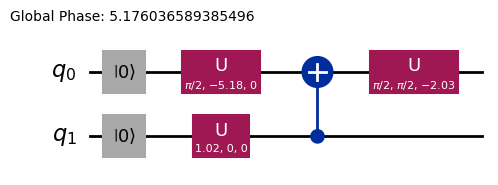

In [6]:
qc.decompose(reps=5).draw(output="mpl")
#reps is the recursion depth for decomposition, not the number of times the circuit is repeated

Where,

The Qiskit U gate is equivalent to:

$U(θ,ϕ,λ)$=$R_\text{Z}(ϕ)$ $R_\text{Y}(θ)$ $R_\text{Z}(λ)$

This is called the ZYZ decomposition.

$U(θ,φ,λ)$:

$θ$  → controls the amount of $|0⟩$ and $|1⟩ $


$φ$  → controls phase

$λ$  → controls additional phase

For example:

U(θ,ϕ,λ)=$$
\begin{bmatrix}
\cos\frac{\theta}{2} & -e^{iλ}\sin\frac{\theta}{2}\\
e^{iϕ}\sin\frac{\theta}{2} & e^{i(ϕ+λ)}\cos\frac{\theta}{2} \\
\end{bmatrix}
$$

# Difference between Statevector and initialize()

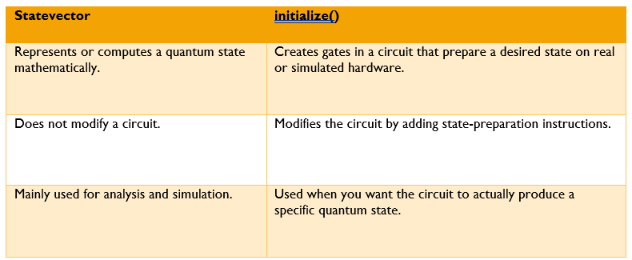

### 3. Angle Encoding
In angle encoding:

*   Each feature value is mapped to a corresponding qubit, $\vec{x}^{(j)}_k \rightarrow Q_k$, leaving the qubits in a product state.
*   One numerical value is encoded at a time, rather than a whole set of features from a data point.
*   $n$ qubits are required for $N$ data features, where $n\leq N$. Often equality holds, here. We'll see how $n<N$ is possible in the next few sections.
*   The resulting circuit is a constant depth (typically the depth is 1 prior to transpilation).

The angle encoding can be implemented using any rotation gate. One additional feature of encoding our data using  Y-rotation is that it creates real-valued quantum states that can be useful for certain applications. The data has to be rescaled so that $\vec{x}^{(j)}_k \in (0,2\pi]$, preventing information loss and other unwanted effects.

The following Qiskit code rotates a single qubit from an initial state $|0\rangle$ to encode a data value $\vec{x}^{(j)}_k=\frac{1}{2}\pi$.

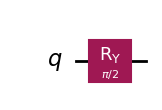

In [7]:
from qiskit.quantum_info import Statevector
from math import pi

qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc) # Statevector is used to calculate the quantum state of the circuit(no measurement).
qc.ry(pi / 2, 0)  # ROTATION gate rotates by an angle pi/2
qc.draw("mpl")

In [8]:
state2 = Statevector.from_instruction(qc)

In [9]:
print(state1)
print(state2)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


where,

α=1+0i

β=0+0i.

**dims=(2,)**:

This describes the dimensions of the quantum system.

Since you have one qubit, its Hilbert space has dimension 2.

That was just a single feature of a single data vector. When encoding $N$ features into the rotation angles of $n$ qubits, say for the $j^\text{th}$ data vector $\vec{x}^{(j)} = (x_1,...,x_N),$ the encoded product state will look like this:
$$
|\vec{x}^{(j)}\rangle = \bigotimes^N_{k=1} R_Y(2\vec{x}^{(j)}_k)|0\rangle= \bigotimes^N_{k=1} \cos(\vec{x}^{(j)}_k)|0\rangle + \sin(\vec{x}^{(j)}_k)|1\rangle
$$

In [10]:
#Extract the quantum state amplitudes and probabilities
amplitudes = state2.data
probabilities = state2.probabilities_dict()
print(amplitudes)
print(probabilities)
print("\nMeasurement Probabilities for each computational state:")
for state_str, prob in probabilities.items():
    print(f"State |{state_str}⟩: {prob:.3f} (or {prob*100:.1f}%)")

[0.70710678+0.j 0.70710678+0.j]
{np.str_('0'): np.float64(0.5000000000000001), np.str_('1'): np.float64(0.4999999999999999)}

Measurement Probabilities for each computational state:
State |0⟩: 0.500 (or 50.0%)
State |1⟩: 0.500 (or 50.0%)


Using Libraries:

In [11]:
from qiskit_machine_learning.circuit.library import raw_feature_vector
import numpy as np
from sklearn.preprocessing import normalize

# Create an amplitude encoding block for 4 features (requires log2(4) = 2 qubits)
amplitude_map = raw_feature_vector(feature_dimension=4)

feature = [[5, 8, 3, 1]]
normalization = normalize(feature)
# Define your data vector (must be normalized so the squares sum to 1)
row_data = normalization.flatten()

# Bind the data to the circuit
encoded_amplitude_circuit = amplitude_map.assign_parameters(row_data)
print(encoded_amplitude_circuit.draw("text"))

     ┌──────────────────────────────────────────────────────────┐
q_0: ┤0                                                         ├
     │  Parameterizedinitialize(0.50252,0.80403,0.30151,0.1005) │
q_1: ┤1                                                         ├
     └──────────────────────────────────────────────────────────┘


ParameterizedInitialize-> A state initialization goes here, but the exact values will be supplied later as parameters.


*   `amplitude_map = RawFeatureVector(feature_dimension=4)`. At this stage, Qiskit creates an abstract blueprint circuit with a ParameterizedInitialize box. It doesn't contain your data yet; it just holds generic parameter variables (like ParameterVectorElement(x[0]))
*   When you call `.assign_parameters(row_data)`, Qiskit substitutes your actual numbers (0.50252, 0.80403, ...) into those placeholders.



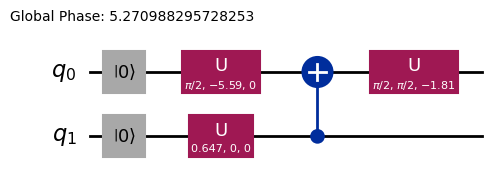

In [47]:
decomposed_circuit=encoded_amplitude_circuit.decompose(reps=7)
decomposed_circuit.draw("mpl")

In [13]:
decomposed_circuit.data

[CircuitInstruction(operation=Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='u', num_qubits=1, num_clbits=0, params=[1.5707963267948966, -5.592738850124895, 0.0]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=()), CircuitInstruction(operation=Instruction(name='u', num_qubits=1, num_clbits=0, params=[0.6468605943909793, 2.220446049250313e-16, 0.0]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=()), CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=1>, <Qubit register=(2, "q"), index=0>), clbits=()), CircuitInstruction(operation=Instruction(name='u', num_qubits=1, num_clbits=0, params=[1.5707963267948966, 1.570796326794

`decomposed_qc.data` is a Python list containing the sequence of operations inside your quantum circuit.

*   one of the elements inside this list is a CircuitInstruction object.

When you wrap an iterable (like your list of circuit data) in `enumerate()`, it generates pairs of values for every single element in that list: `(index, element)`


*   `idx` (The Counter): This is the current positional index of the item in the list, starting automatically at 0
*   `item` (The Object): This is the actual `CircuitInstruction` object itself at that position.

`gate = item.operation`
This extracts the internal `Instruction ` object.

`qubits = item.qubits`
This extracts the tuple of qubits that this specific operation acts upon.





Extracting the Raw Matrix Data:

In [29]:
from qiskit.quantum_info import Operator
# The `Operator` class knows how to convert a gate into its matrix representation.

# Loop through and inspect the blocks
for idx, item in enumerate(decomposed_circuit.data):
    gate = item.operation
    print(gate)
    qubits = item.qubits
    print(qubits)

    # Check if the block is a single-qubit 'u' gate
    if gate.name == 'u':
        # Safely find the integer indices of the qubits
        qubit_indices = [decomposed_circuit.find_bit(q).index for q in qubits]

        print(f"Block #{idx}: UNITARY Gate on Qubits {qubit_indices}")

        # CORRECT WAY: Convert the gate instruction into a numerical matrix operator
        matrix_array = Operator(gate).data

        print("Raw Matrix Array:")
        print(matrix_array)
        print("-" * 50)


Instruction(name='reset', num_qubits=1, num_clbits=0, params=[])
(<Qubit register=(2, "q"), index=0>,)
Instruction(name='u', num_qubits=1, num_clbits=0, params=[1.5707963267948966, -5.592738850124895, 0.0])
(<Qubit register=(2, "q"), index=0>,)
Block #1: UNITARY Gate on Qubits [0]
Raw Matrix Array:
[[ 0.70710678+0.j         -0.70710678-0.j        ]
 [ 0.54515228+0.45034319j  0.54515228+0.45034319j]]
--------------------------------------------------
Instruction(name='reset', num_qubits=1, num_clbits=0, params=[])
(<Qubit register=(2, "q"), index=1>,)
Instruction(name='u', num_qubits=1, num_clbits=0, params=[0.6468605943909793, 2.220446049250313e-16, 0.0])
(<Qubit register=(2, "q"), index=1>,)
Block #3: UNITARY Gate on Qubits [1]
Raw Matrix Array:
[[ 0.94815078+0.00000000e+00j -0.31782086-0.00000000e+00j]
 [ 0.31782086+7.05704080e-17j  0.94815078+2.10531765e-16j]]
--------------------------------------------------
Instruction(name='cx', num_qubits=2, num_clbits=0, params=[])
(<Qubit reg

# z_feature_map

The ZFeatureMap performs

$\vert 0 \rangle \rightarrow H \rightarrow R_Z(x_i)$


for each feature.

*reps=1 means -->One encoding layer.*

In [15]:
from qiskit.circuit.library import z_feature_map

# 1. Create the feature map for a 5-column dataframe
feature_map = z_feature_map(feature_dimension=5, reps=1)

# 2. Feed it a row of data (must be an array/list of 5 scaled values)
my_dataframe_row = [0.2, 1.5, 2.1, 0.8, 3.0]
encoded_circuit = feature_map.assign_parameters(my_dataframe_row)

print(encoded_circuit.draw("text"))

   ┌───┐┌────────┐
0: ┤ H ├┤ P(0.4) ├
   ├───┤└┬──────┬┘
1: ┤ H ├─┤ P(3) ├─
   ├───┤┌┴──────┴┐
2: ┤ H ├┤ P(4.2) ├
   ├───┤├────────┤
3: ┤ H ├┤ P(1.6) ├
   ├───┤└┬──────┬┘
4: ┤ H ├─┤ P(6) ├─
   └───┘ └──────┘ 


### 4. Phase Encoding
The phase encoding procedure maps each feature value to the phase $\phi$ of a corresponding qubit, $\vec{x}^{(j)}_k \rightarrow Q_k$. In total, phase encoding has a circuit depth of 2, including the Hadamard layer, which makes it an efficient encoding scheme. The phase-encoded multi-qubit state ($n$ qubits for $N=n$ features) is a product state:
$$
|\vec{x}^{(j)}\rangle = \bigotimes_{k=1}^{N} P_k(\phi = \vec{x}^{(j)}_k)|+\rangle^{\otimes N} = {\textstyle\frac{1}{\sqrt{2^N}}} \bigotimes_{k=1}^{N}\big(|0\rangle + e^{i\vec{x}^{(j)}_k}|1\rangle\big).
$$

The following Qiskit code first prepares the initial state of a single qubit by rotating it with a Hadamard gate, then phase-ecodes the data point $\vec{x}^{(j)}_k=\frac{1}{2}\pi$ using a phase gate.


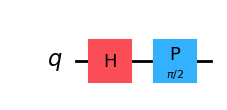

In [34]:
from qiskit.quantum_info import Statevector
from math import pi
qc = QuantumCircuit(1)
qc.h(0)  # Hadamard gate rotates state down to Bloch equator
#the state lies on the equator of the Bloch sphere.
state1 = Statevector.from_instruction(qc) #This stores the current quantum state. It does not change the circuit.

qc.p(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)

states = state1, state2

qc.draw("mpl", scale=1)

In [30]:
print(state1)
print(state2)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Statevector([0.83146961+0.j, 0.55557023+0.j],
            dims=(2,))


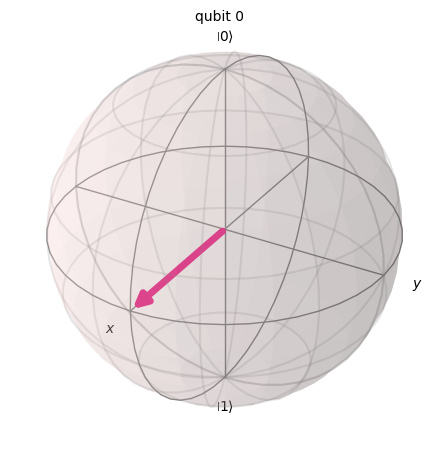

In [38]:
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

plot_bloch_multivector(states[0])

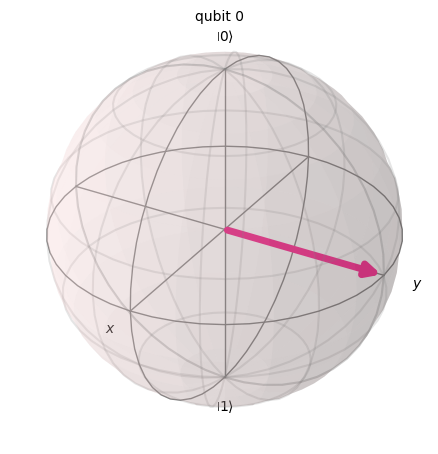

In [39]:
plot_bloch_multivector(states[1])




*   Phase encoding is the encoding principle.
*  Z Feature Map is one particular implementation of that principle for quantum machine learning, packaged as a reusable parameterized circuit



### 5. Dense angle encoding

Dense angle encoding (DAE) is a combination of angle encoding and phase encoding. DAE allows two feature values to be encoded in a single qubit: $\theta$ with a Y-axis rotation , and $\phi$ with a $z$-axis rotation. Encoding two data features to one qubit results in a $2$-times reduction in the number of qubits required for the encoding. Extending this to more features, the data vector $\vec{x} = (x_1,...,x_N)$ can be encoded as:

$$
|\vec{x}\rangle = \bigotimes_{k=1}^{N/2} \cos(x_{2k-1})|0\rangle + e^{i x_{2k}}\sin(x_{2k-1})|1\rangle
$$

DAE can be generalized to arbitrary functions of the two features instead of the sinusoidal functions used here. This is called general qubit encoding.

As an example of DAE, the code below encodes and visualizes the encoding of the features $x_1=\theta = 3\pi/8$ and $x_2=\phi = 7\pi/4$.

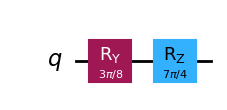

In [40]:
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(3 * pi / 8, 0)
state2 = Statevector.from_instruction(qc)
qc.rz(7 * pi / 4, 0)
state3 = Statevector.from_instruction(qc)
states = state1, state2, state3

qc.draw("mpl", scale=1)

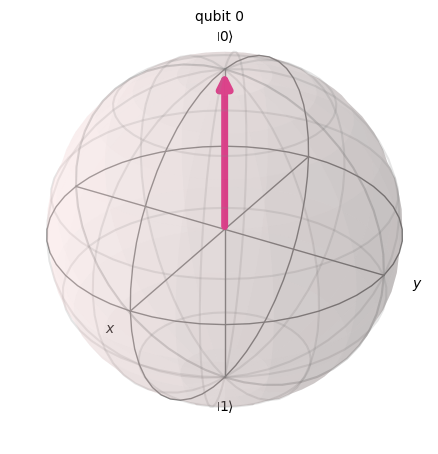

In [42]:
plot_bloch_multivector(state1)

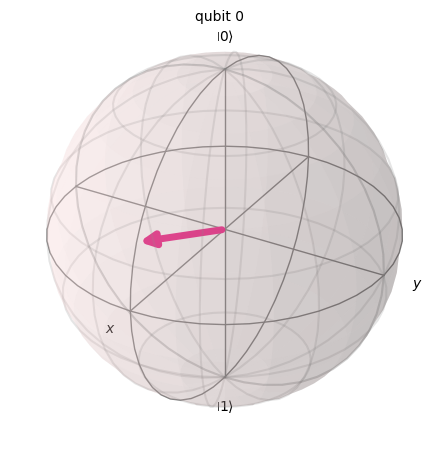

In [43]:
plot_bloch_multivector(state2)

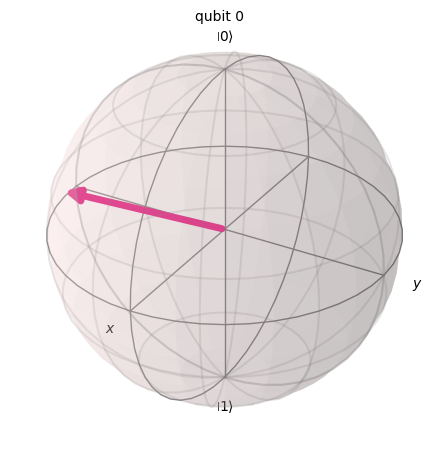

In [44]:
plot_bloch_multivector(state3)



*   RY changes the polar angle on the Bloch sphere. This changes the amplitudes of $∣0⟩$ and $∣1⟩$, so the measurement probabilities change.
*   RZ changes the azimuthal angle. It changes only the relative phase between the amplitudes, leaving the measurement probabilities unchanged.


### 6. Efficient SU2
Since amplitudes in a statevector are complex numbers, a single qubit state has four real parameters (though constrained by the requirement of normalization), a two qubit state has eight real parameters, and so on. The Efficient SU2 scheme can encode many more data points with fewer qubits. For example, a two qubit state with a single repetition is
$$
\begin{align}
\nonumber
|\psi\rangle_{\text{final}} &= \cos(\theta_0/2)
\left(\cos(\theta_4/2)|0\rangle+\sin(\theta_4/2)e^{i\theta_6}|1\rangle\right)\\ \nonumber
&\otimes \left[ \cos(\theta_1/2)
    \left( \cos(\theta_5/2)|0\rangle+\sin(\theta_5/2)e^{i \theta_7}|1\rangle\right)
+\sin(\theta_1/2)e^{i\theta_3}\left(-\sin(\theta_5/2)|0\rangle+\cos(\theta_5/2)e^{i \theta_7}|1\rangle\right)
    \right]\\ \nonumber
&+\sin(\theta_0/2)e^{i\theta_2}
\left(-\sin(\theta_4/2)|0\rangle+\cos(\theta_4/2)e^{i\theta_6}|1\rangle\right)\\ \nonumber
&\otimes \left[
\sin(\theta_1/2)e^{i\theta_3}\left(\cos(\theta_5/2)|0\rangle+\sin(\theta_5/2)e^{i \theta_7}|1\rangle\right)
+\cos(\theta_1/2)e^{i\theta_3}\left(-\sin(\theta_5/2)|0\rangle+\cos(\theta_5/2)e^{i \theta_7}|1\rangle\right)
\right]
\end{align}
$$

It is called EfficientSU2. Because, it uses

*   few gates
*   shallow circuits

which makes it suitable for current noisy quantum computers.



*   SU(2) is the mathematical group of all 2×2 unitary matrices with determinant 1.

*   Every single-qubit rotation belongs to SU(2). So each rotation layer explores the space of single-qubit operations.



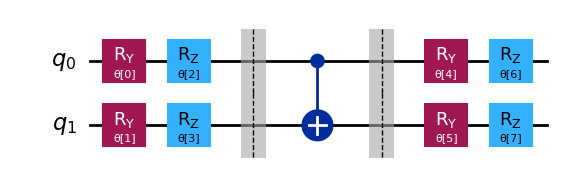

In [18]:
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
circuit.draw(output="mpl")

However, we can encode more parameters with two qubits, though the state will not be unique any more

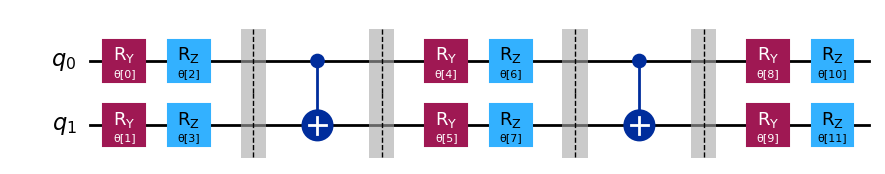

In [19]:
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=2, insert_barriers=True)
circuit.draw(output="mpl")

we can assign parameters after creating the circuit

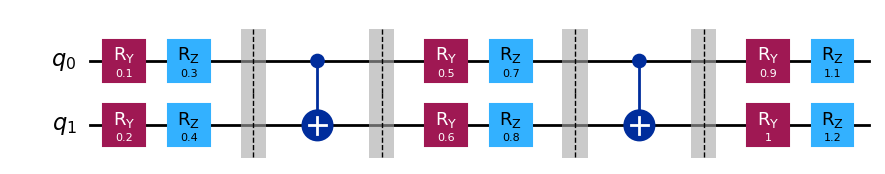

In [20]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=2, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.draw(output="mpl")

another example with three qubits

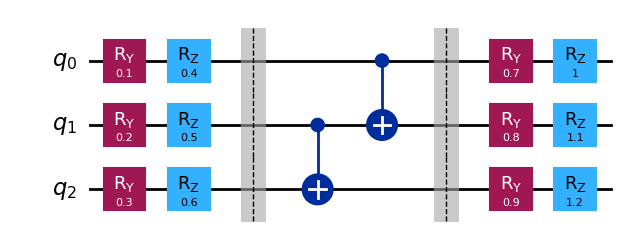

In [21]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.draw(output="mpl")

### 7. Z Feature Map
The $Z$ feature map (ZFM) can be interpreted as a natural extension of phase encoding. The ZFM consists of alternating layers  of Hadamard gates and phase gates. Let the data vector $\vec{x}$ have $N$ features.  The data features $x_i$ are mapped one-to-one with corresponding qubits.  The full ZFM circuit unitary with a single repetition is:

$$
\mathscr{U}_{\text{ZFM}}=\big(P(\vec{x}_1)\otimes\ldots P(\vec{x}_k)\otimes\ldots P(\vec{x}_N)H^{\otimes N}\big)=\left(\bigotimes_{k = 1}^N P(\vec{x}_k)\right)H^{\otimes N}
$$

Then $r$ repetitions of this unitary would be

$$
\mathscr{U}^{(r)}_{\text{ZFM}}\left(\vec{x}\right)=\prod_{s=1}^{r}\left[\left(\bigotimes_{k = 1}^N P(\vec{x}_k)\right)H^{\otimes N}\right]
$$

The data features, $x_k$, are mapped to the phase gates in the same way in all $r$ repetitions.

 The following Qiskit code uses Hadamard and phase gates explicitly to show the structure of the ZFM:

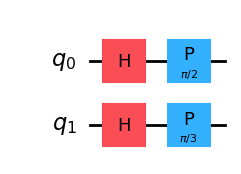

In [22]:
qc0 = QuantumCircuit(1)
qc1 = QuantumCircuit(1)

qc0.h(0)
qc0.p(pi / 2, 0)

qc1.h(0)
qc1.p(pi / 3, 0)

# Combine circuits qc0 and qc1 into 1 circuit
qc = QuantumCircuit(2)
qc.compose(qc0, [0], inplace=True)
qc.compose(qc1, [1], inplace=True)

qc.draw("mpl", scale=1)

### 8. ZZ Feature Map
The $ZZ$ feature map (ZZFM) extends the ZFM with the inclusion of two-qubit entangling gates, specifically the $ZZ$-rotation gate $R_{ZZ}(\theta)$. The ZZFM is conjectured to be generally expensive to compute on a classical computer, unlike the ZFM.

A single repetition of the ZZFM circuit is:

$$
\mathscr{U}_{\text{ZZFM}}(\vec{x}) = R_{ZZ,q,p}(\theta_{q,p})(\vec{x})\left(\bigotimes_{k = 1}^N P(\vec{x}_k)\right)H^{\otimes N},
$$

 Entanglemt schemes can be linear, circular, full etc.  In the phase layer, the qubits p and q have phase gates that encode $\vec{x}_p$ and $\vec{x}_q$ on them, respectively. By default
$$
\theta_{q,p} \rightarrow \phi(\vec{x}_q, \vec{x}_p) = 2(\pi-\vec{x}_q)(\pi-\vec{x}_p).
$$
but we can define our own $\phi$ as well. Also, $R_{ZZ}$ can be replaced by another multi-qubit unitary.


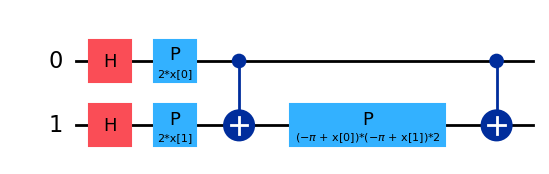

In [23]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 2
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.draw("mpl", scale=1)

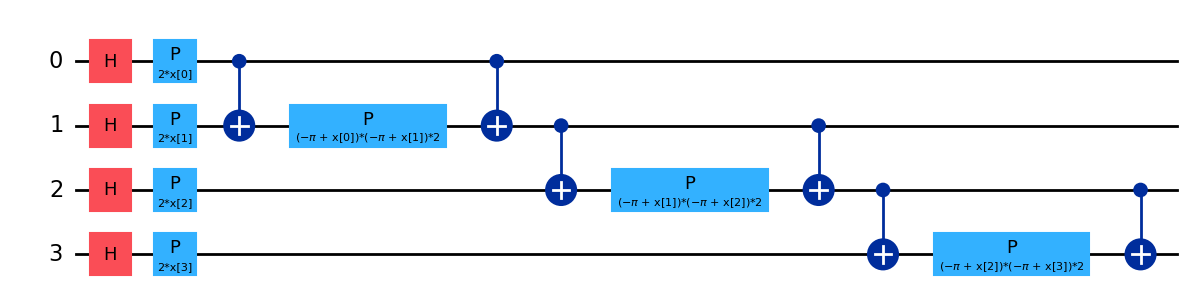

In [24]:
feature_dim = 4
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.draw("mpl", scale=1)

### 9. Pauli feature map

The Pauli feature map (PFM) is the generalization of the ZFM and ZZFM to use arbitrary Pauli gates. The Pauli feature map takes a very similar form to the previous two feature maps. For $r$ repetitions of the encoding of the $N$ features of vector $\vec{x},$

$$
\mathscr{U}_{\text{PFM}}(\vec{x}) = \prod_{s=1}^{r} U(\vec{x}) H^{\otimes n}.
$$

For PFM, $U(\vec{x})$ is generalized to a Pauli expansion unitary operator. Here we present a more generalized form of the feature maps considered so far:

$$
U(\bar{x}) = \exp\left(i \alpha \sum_{S\subseteq[n]} \phi_S(\bar{x}) \prod_{i \in S} \sigma_i \right)
$$

where $\sigma_i$ is a Pauli operator, $\sigma_i \in {I,X,Y,Z}$. Here $\mathcal{I}$ is the set of all qubit connectivities as determined by the feature map, including the set of qubits acted on by single-qubit gates. And

$$
\phi_S(\vec{x})=
    \begin{cases}
      x_i & \text{if } S= \{i\} \text{ (single-qubit)}\\
      \prod_{j\in{S}}(\pi-x_j) & \text{if } |S|\ge2 \text{ (multi-qubit)}\\
    \end{cases}
$$


The default value of $\alpha$ is $2$. By optimizing its value in the interval, for example, $[0,4],$ one can better align a quantum kernel to the data.

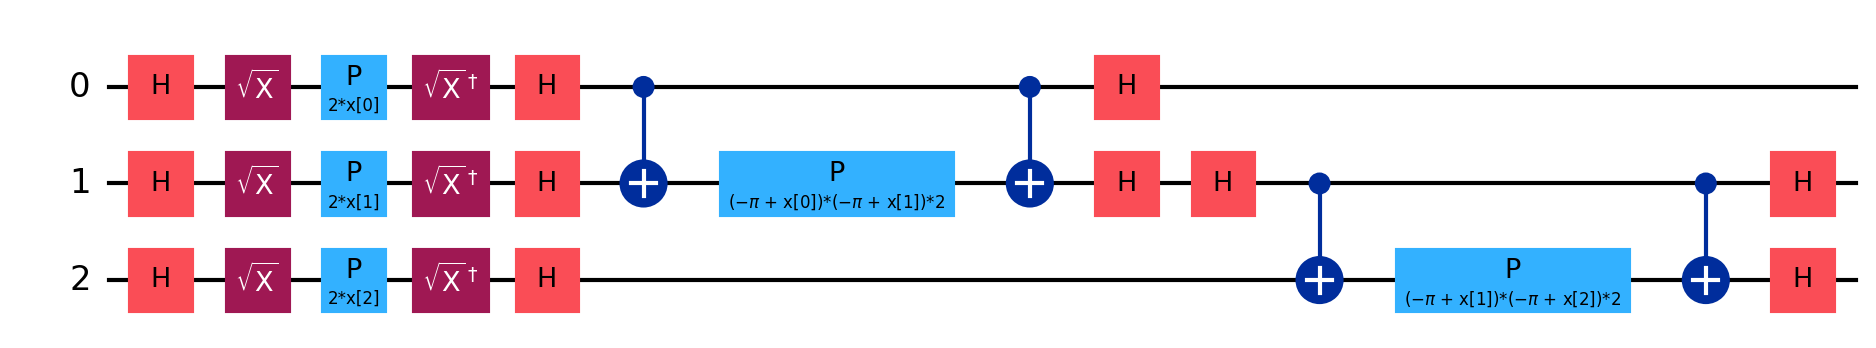

In [25]:
from qiskit.circuit.library import pauli_feature_map

feature_dim = 3
pfmap = pauli_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1, paulis=["Y", "XX"]
)

pfmap.draw("mpl", scale=1.5)

### 10. Two Local
It creates parameterized circuits of alternating rotation and entanglement layers. In both layers, parameterized circuit-blocks act on the circuit in a defined way. In the rotation layer, the blocks are applied stacked on top of each other, while in the entanglement layer according to the entanglement strategy. Each layer is repeated a number of times, and by default a final rotation layer is appended.


/tmp/ipykernel_4410/3370668890.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  twolocal = TwoLocal(num_qubits=5, reps=1, rotation_blocks=['ry','rz'],


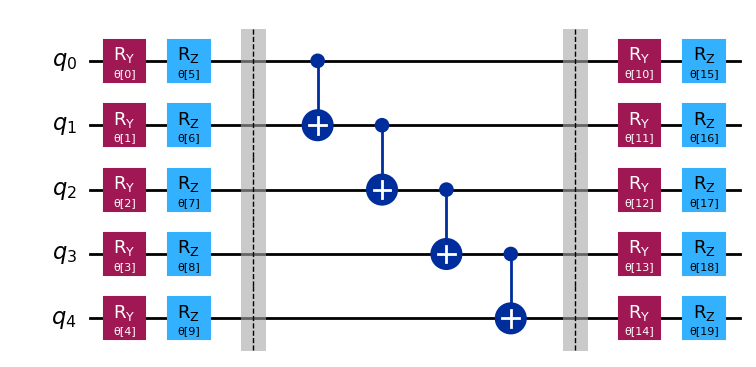

In [26]:
from qiskit.circuit.library import TwoLocal

twolocal = TwoLocal(num_qubits=5, reps=1, rotation_blocks=['ry','rz'],
               entanglement_blocks='cx', entanglement='linear', insert_barriers=True)
twolocal.decompose().draw('mpl')

### 11. NLocal
In NLocal, the circuit blocks can have arbitrary sizes (smaller equal to the number of qubits in the circuit), while in TwoLocal, the rotation layers are single qubit gates applied on all qubits and the entanglement layer uses two-qubit gates.

/tmp/ipykernel_4410/2954615515.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.n_local.NLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. This applies to NLocal subclasses too. Use the corresponding function from the module qiskit.circuit.library.n_local instead.
  twolocaln = NLocal(num_qubits=3, reps=2,


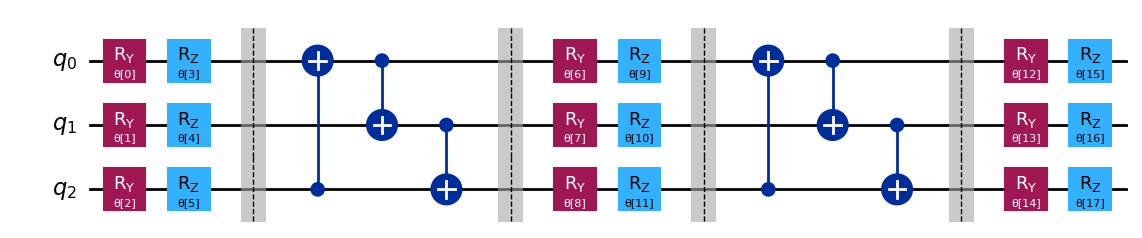

In [27]:
from qiskit.circuit.library import TwoLocal, NLocal, RYGate, RZGate, CXGate
from qiskit.circuit import Parameter
a=Parameter('a')
b=Parameter('b')
twolocaln = NLocal(num_qubits=3, reps=2,
               rotation_blocks=[RYGate(a), RZGate(b)],
               entanglement_blocks=CXGate(),
               entanglement='circular', insert_barriers=True)
twolocaln.decompose().draw('mpl')

We also encode parameters inside the rotation blocks as

/tmp/ipykernel_4410/1637313997.py:16: DeprecationWarning: The class ``qiskit.circuit.library.n_local.n_local.NLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. This applies to NLocal subclasses too. Use the corresponding function from the module qiskit.circuit.library.n_local instead.
  nlocal = NLocal(num_qubits=6, rotation_blocks=rot, entanglement_blocks=ent,


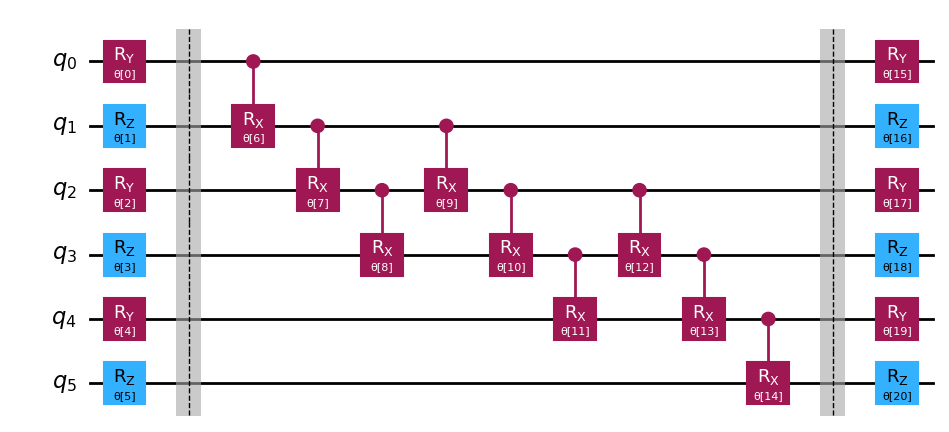

In [28]:
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import NLocal
# rotation block:
rot = QuantumCircuit(2)
params = ParameterVector('r', 2)
rot.ry(params[0], 0)
rot.rz(params[1], 1)

# entanglement block:
ent = QuantumCircuit(4)
params = ParameterVector('e', 3)
ent.crx(params[0], 0, 1)
ent.crx(params[1], 1, 2)
ent.crx(params[2], 2, 3)

nlocal = NLocal(num_qubits=6, rotation_blocks=rot, entanglement_blocks=ent,
                entanglement='linear', insert_barriers=True)
nlocal.decompose().draw('mpl')